# Vasicek et CIR

### Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('figures', exist_ok=True)

### Définition des paramèters globaux et fonctions de simulations

In [3]:
T  = 10.0
N  = 2000
dt = T / N
t  = np.linspace(0.0, T, N + 1)
r0 = 0.05


def simulate_vasicek(a, b, sigma):
    r = np.zeros(N + 1)
    r[0] = r0
    for i in range(N):
        m      = r[i] * np.exp(-a * dt) + b * (1.0 - np.exp(-a * dt))
        s2     = sigma**2 / (2.0 * a) * (1.0 - np.exp(-2.0 * a * dt))
        r[i+1] = m + np.sqrt(s2) * np.random.randn()
    integral = np.zeros(N + 1)
    integral[1:] = np.cumsum(r[:-1]) * dt
    B = np.exp(integral)
    return r, B


def simulate_cir(a, b, sigma):
    r = np.zeros(N + 1)
    r[0] = r0
    for i in range(N):
        c      = sigma**2 * (1.0 - np.exp(-a * dt)) / (4.0 * a)
        d      = 4.0 * a * b / sigma**2
        lam    = 4.0 * a * np.exp(-a * dt) * r[i] / (sigma**2 * (1.0 - np.exp(-a * dt)))
        r[i+1] = c * np.random.noncentral_chisquare(d, lam)
    integral = np.zeros(N + 1)
    integral[1:] = np.cumsum(r[:-1]) * dt
    B = np.exp(integral)
    return r, B

## Trajectoire de référence

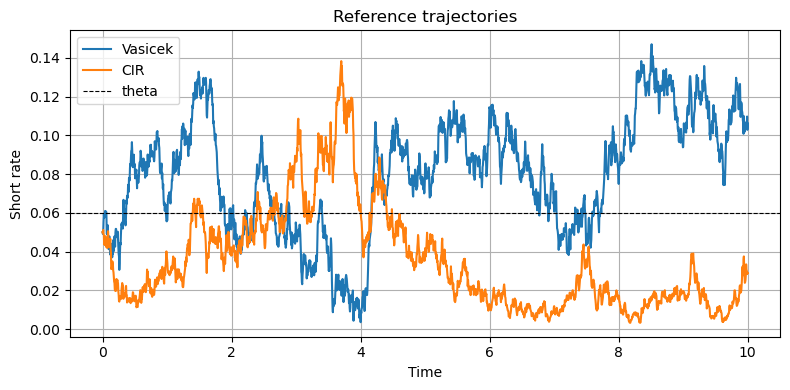

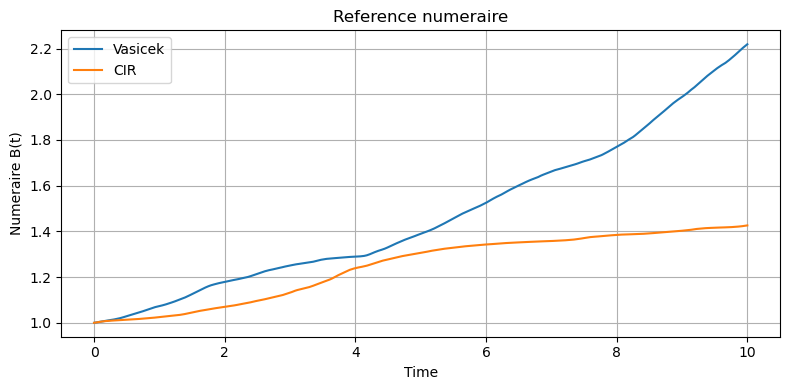

In [4]:
# ============================
# Parameters
# ============================
a     = 0.5
b     = 0.06
sig_v = 0.05
sig_c = 0.20

# ============================
# Simulation
# ============================
r_v, B_v = simulate_vasicek(a, b, sig_v)
r_c, B_c = simulate_cir(a, b, sig_c)

# ============================
# Plots
# ============================
plt.figure(figsize=(8, 4))
plt.plot(t, r_v, label='Vasicek')
plt.plot(t, r_c, label='CIR')
plt.axhline(b, color='k', ls='--', lw=0.8, label='theta')
plt.xlabel('Time'); plt.ylabel('Short rate')
plt.title('Reference trajectories')
plt.legend(); plt.grid(); plt.tight_layout()
plt.savefig('figures/01_reference_rate.png', dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, B_v, label='Vasicek')
plt.plot(t, B_c, label='CIR')
plt.xlabel('Time'); plt.ylabel('Numeraire B(t)')
plt.title('Reference numeraire')
plt.legend(); plt.grid(); plt.tight_layout()
plt.savefig('figures/01_reference_numeraire.png', dpi=150)
plt.show()

## Grille sur le paramètre kappa

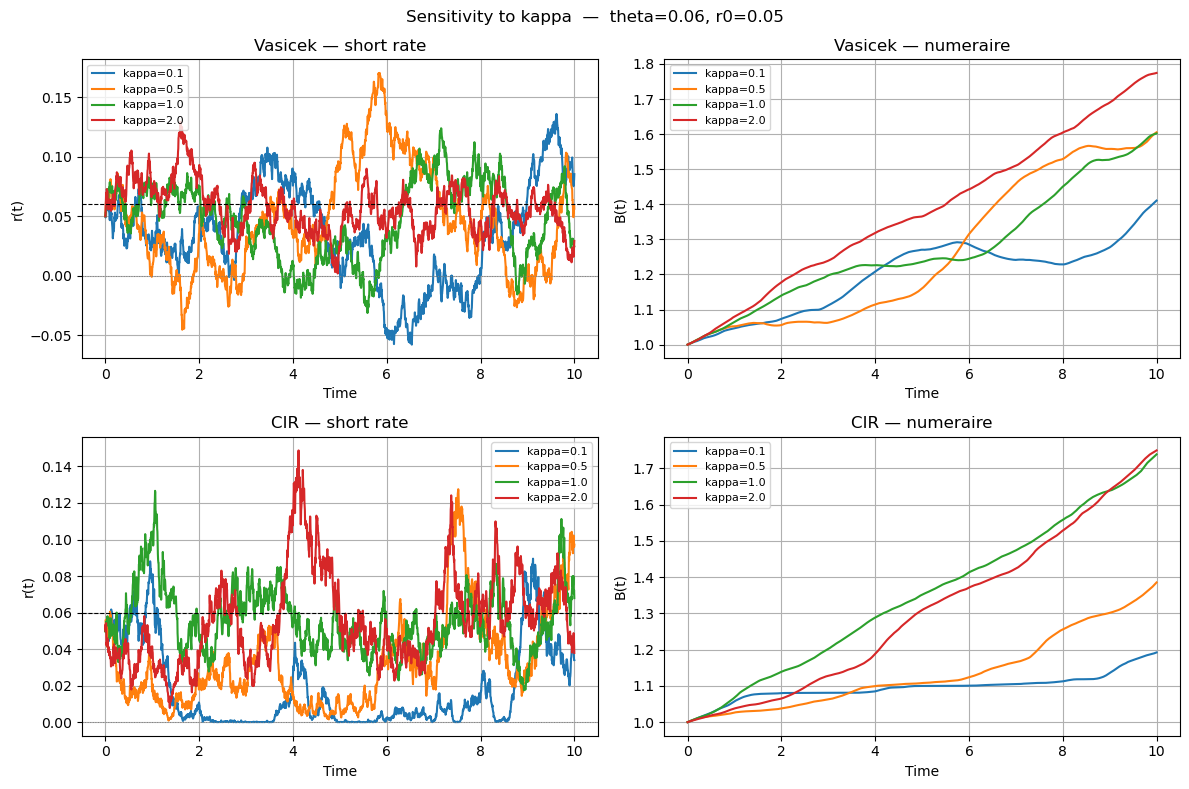

In [5]:
# ============================
# Parameters
# ============================
b          = 0.06
sig_v      = 0.05
sig_c      = 0.20
kappa_grid = [0.1, 0.5, 1.0, 2.0]

# ============================
# Simulation & plot
# ============================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for a in kappa_grid:
    r_v, B_v = simulate_vasicek(a, b, sig_v)
    r_c, B_c = simulate_cir(a, b, sig_c)
    axes[0, 0].plot(t, r_v, label=f'kappa={a}')
    axes[0, 1].plot(t, B_v, label=f'kappa={a}')
    axes[1, 0].plot(t, r_c, label=f'kappa={a}')
    axes[1, 1].plot(t, B_c, label=f'kappa={a}')

for ax in [axes[0, 0], axes[1, 0]]:
    ax.axhline(b, color='k', ls='--', lw=0.8)
    ax.axhline(0, color='gray', ls=':', lw=0.7)

axes[0, 0].set_title('Vasicek — short rate');  axes[0, 0].set_ylabel('r(t)')
axes[0, 1].set_title('Vasicek — numeraire');   axes[0, 1].set_ylabel('B(t)')
axes[1, 0].set_title('CIR — short rate');      axes[1, 0].set_ylabel('r(t)')
axes[1, 1].set_title('CIR — numeraire');       axes[1, 1].set_ylabel('B(t)')

for ax in axes.flat:
    ax.set_xlabel('Time'); ax.legend(fontsize=8); ax.grid()

plt.suptitle('Sensitivity to kappa  —  theta=0.06, r0=0.05')
plt.tight_layout()
plt.savefig('figures/02_kappa.png', dpi=150)
plt.show()

## Grille sur le paramètre theta

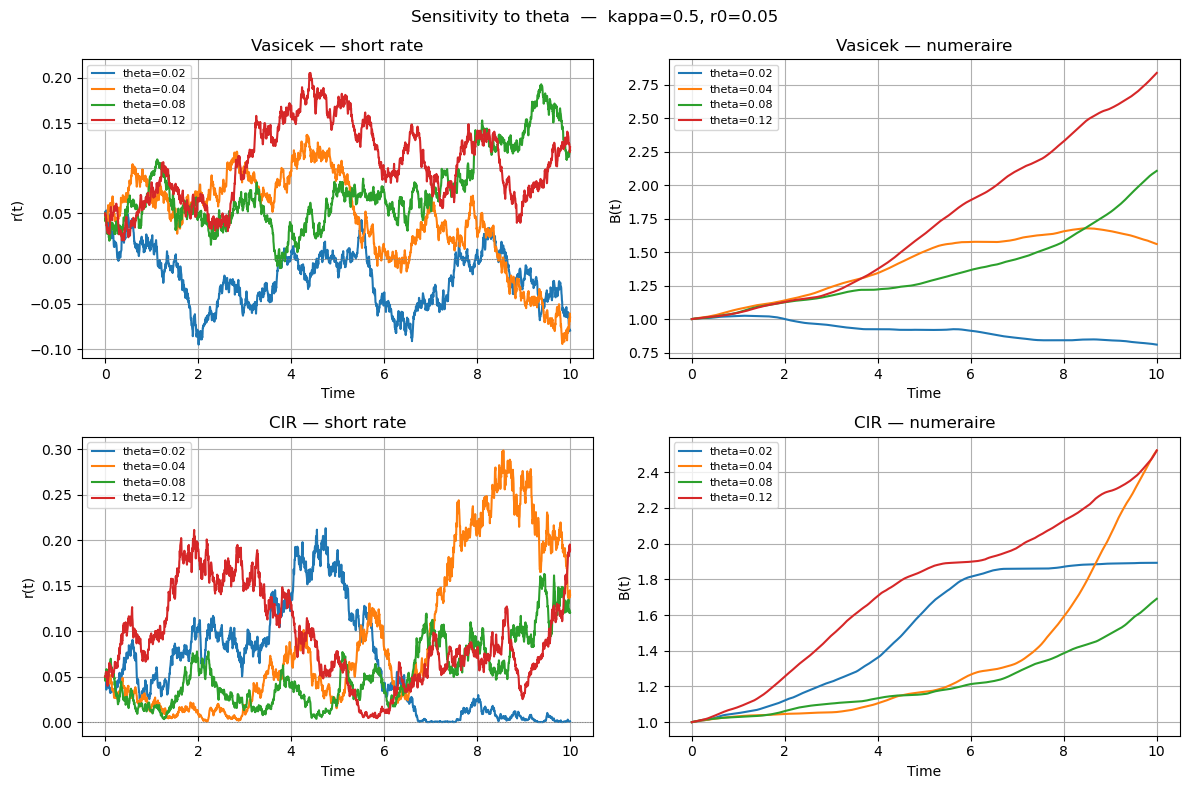

In [6]:
# ============================
# Parameters
# ============================
a          = 0.5
sig_v      = 0.05
sig_c      = 0.20
theta_grid = [0.02, 0.04, 0.08, 0.12]

# ============================
# Simulation & plot
# ============================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for b in theta_grid:
    r_v, B_v = simulate_vasicek(a, b, sig_v)
    r_c, B_c = simulate_cir(a, b, sig_c)
    axes[0, 0].plot(t, r_v, label=f'theta={b}')
    axes[0, 1].plot(t, B_v, label=f'theta={b}')
    axes[1, 0].plot(t, r_c, label=f'theta={b}')
    axes[1, 1].plot(t, B_c, label=f'theta={b}')

for ax in [axes[0, 0], axes[1, 0]]:
    ax.axhline(0, color='gray', ls=':', lw=0.7)

axes[0, 0].set_title('Vasicek — short rate');  axes[0, 0].set_ylabel('r(t)')
axes[0, 1].set_title('Vasicek — numeraire');   axes[0, 1].set_ylabel('B(t)')
axes[1, 0].set_title('CIR — short rate');      axes[1, 0].set_ylabel('r(t)')
axes[1, 1].set_title('CIR — numeraire');       axes[1, 1].set_ylabel('B(t)')

for ax in axes.flat:
    ax.set_xlabel('Time'); ax.legend(fontsize=8); ax.grid()

plt.suptitle('Sensitivity to theta  —  kappa=0.5, r0=0.05')
plt.tight_layout()
plt.savefig('figures/03_theta.png', dpi=150)
plt.show()

## Grille sur le paramètre sigma

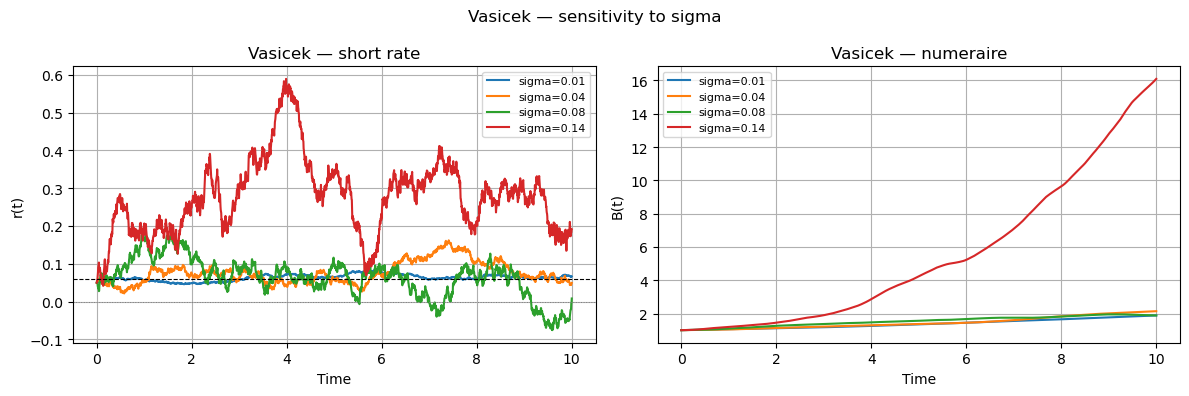

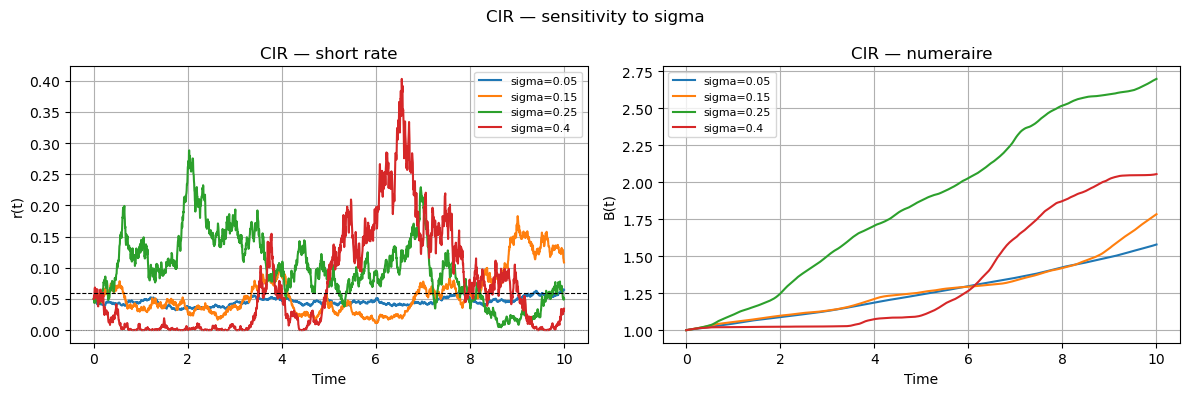

In [7]:
# ============================
# Parameters
# ============================
a = 0.5
b = 0.06
# Plages différentes : dans CIR la volatilité effective est sigma*sqrt(r)
sigma_v_grid = [0.01, 0.04, 0.08, 0.14]
sigma_c_grid = [0.05, 0.15, 0.25, 0.40]

# ============================
# Vasicek — grille sigma
# ============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sig_v in sigma_v_grid:
    r_v, B_v = simulate_vasicek(a, b, sig_v)
    axes[0].plot(t, r_v, label=f'sigma={sig_v}')
    axes[1].plot(t, B_v, label=f'sigma={sig_v}')

axes[0].axhline(b, color='k', ls='--', lw=0.8)
axes[0].axhline(0, color='gray', ls=':', lw=0.7)
axes[0].set_title('Vasicek — short rate'); axes[0].set_ylabel('r(t)')
axes[1].set_title('Vasicek — numeraire');  axes[1].set_ylabel('B(t)')
for ax in axes:
    ax.set_xlabel('Time'); ax.legend(fontsize=8); ax.grid()

plt.suptitle('Vasicek — sensitivity to sigma')
plt.tight_layout()
plt.savefig('figures/04_sigma_vasicek.png', dpi=150)
plt.show()

# ============================
# CIR — grille sigma
# ============================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for sig_c in sigma_c_grid:
    r_c, B_c = simulate_cir(a, b, sig_c)
    axes[0].plot(t, r_c, label=f'sigma={sig_c}')
    axes[1].plot(t, B_c, label=f'sigma={sig_c}')

axes[0].axhline(b, color='k', ls='--', lw=0.8)
axes[0].axhline(0, color='gray', ls=':', lw=0.7)
axes[0].set_title('CIR — short rate'); axes[0].set_ylabel('r(t)')
axes[1].set_title('CIR — numeraire');  axes[1].set_ylabel('B(t)')
for ax in axes:
    ax.set_xlabel('Time'); ax.legend(fontsize=8); ax.grid()

plt.suptitle('CIR — sensitivity to sigma')
plt.tight_layout()
plt.savefig('figures/04_sigma_cir.png', dpi=150)
plt.show()

## Comparaison Vasicek et CIR

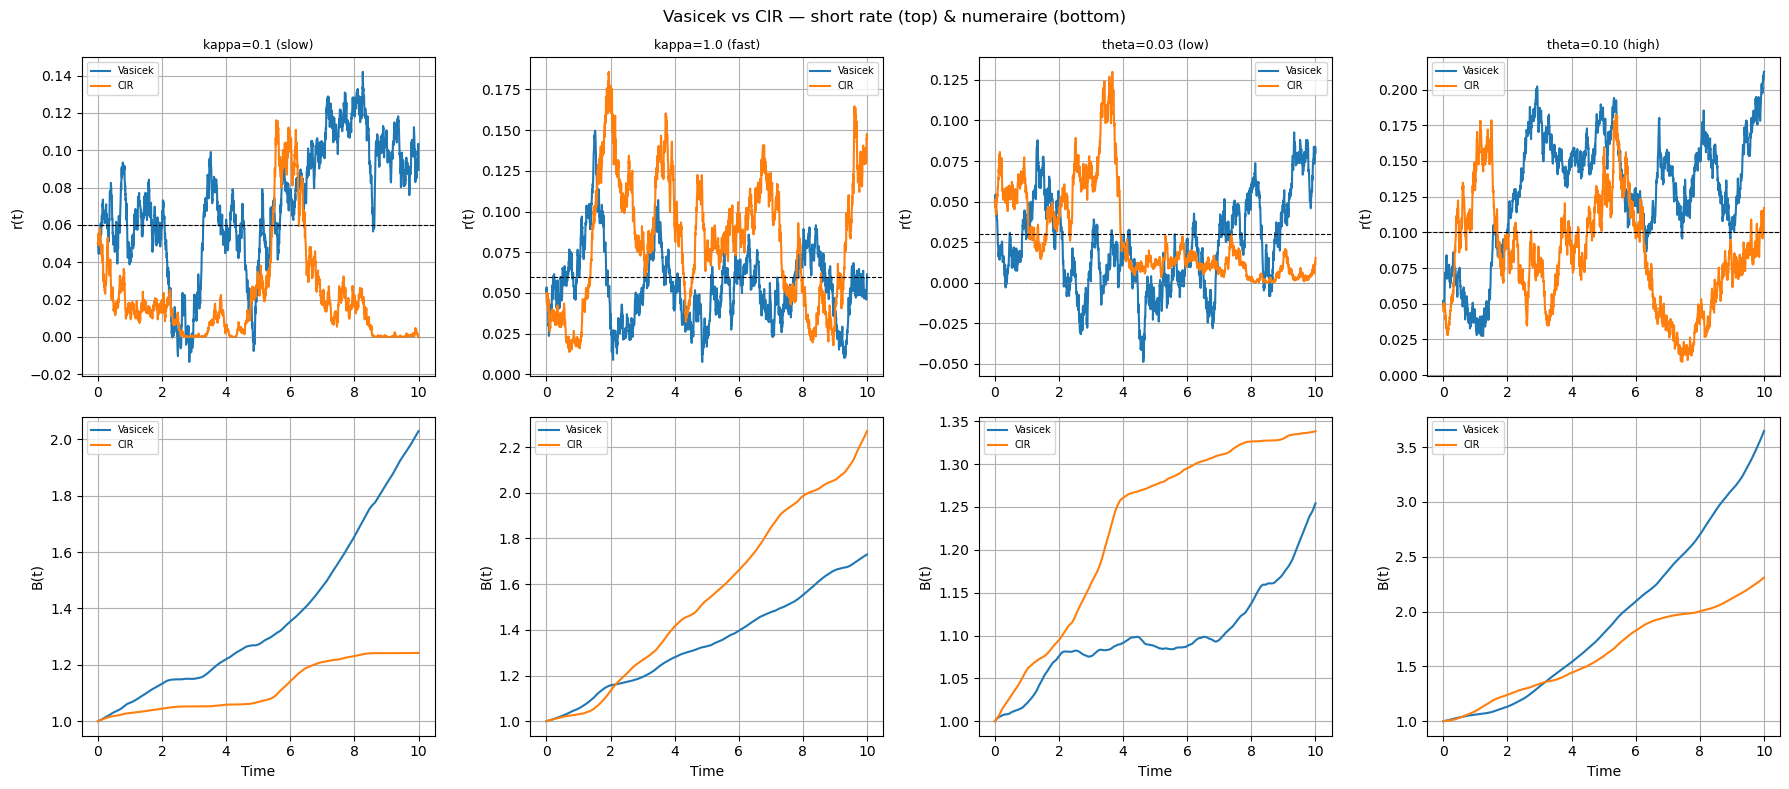

In [8]:
# ============================
# Parameters
# ============================
sig_v = 0.05
sig_c = 0.20

configs = [
    {'a': 0.1, 'b': 0.06, 'label': 'kappa=0.1 (slow)'},
    {'a': 1.0, 'b': 0.06, 'label': 'kappa=1.0 (fast)'},
    {'a': 0.5, 'b': 0.03, 'label': 'theta=0.03 (low)'},
    {'a': 0.5, 'b': 0.10, 'label': 'theta=0.10 (high)'},
]

# ============================
# Simulation & plot
# ============================
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, cfg in enumerate(configs):
    r_v, B_v = simulate_vasicek(cfg['a'], cfg['b'], sig_v)
    r_c, B_c = simulate_cir(cfg['a'], cfg['b'], sig_c)

    axes[0, col].plot(t, r_v, label='Vasicek')
    axes[0, col].plot(t, r_c, label='CIR')
    axes[0, col].axhline(cfg['b'], color='k', ls='--', lw=0.8)
    axes[0, col].axhline(0, color='gray', ls=':', lw=0.7)
    axes[0, col].set_title(cfg['label'], fontsize=9)
    axes[0, col].set_ylabel('r(t)'); axes[0, col].legend(fontsize=7); axes[0, col].grid()

    axes[1, col].plot(t, B_v, label='Vasicek')
    axes[1, col].plot(t, B_c, label='CIR')
    axes[1, col].set_ylabel('B(t)'); axes[1, col].legend(fontsize=7); axes[1, col].grid()

for ax in axes[1]:
    ax.set_xlabel('Time')

plt.suptitle('Vasicek vs CIR — short rate (top) & numeraire (bottom)')
plt.tight_layout()
plt.savefig('figures/05_vasicek_vs_cir.png', dpi=150)
plt.show()